In [11]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import math

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [13]:
class TestDataset(torch.utils.data.Dataset):

    def __init__(self, root_dir, img_size=224, limit=500):

        self.paths = [os.path.join(root_dir,f) for f in os.listdir(root_dir)[:limit]]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        return self.transform(img), self.transform(img)

In [14]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = TestDataset(DATA_PATH)
loader = DataLoader(dataset, batch_size=8, shuffle=False)

In [15]:
class Block(nn.Module):

    def __init__(self,a,b):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)


class ProcessingNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            Block(3,64),
            Block(64,64),

            nn.MaxPool2d(2),

            Block(64,128),
            Block(128,128),

            nn.Upsample(scale_factor=2),

            Block(128,64),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [16]:
state = torch.load("RA_resnet18_lambda_0.1.pth")
print(state.keys())

odict_keys(['net.0.net.0.weight', 'net.0.net.0.bias', 'net.0.net.1.weight', 'net.0.net.1.bias', 'net.0.net.1.running_mean', 'net.0.net.1.running_var', 'net.0.net.1.num_batches_tracked', 'net.1.net.0.weight', 'net.1.net.0.bias', 'net.1.net.1.weight', 'net.1.net.1.bias', 'net.1.net.1.running_mean', 'net.1.net.1.running_var', 'net.1.net.1.num_batches_tracked', 'net.3.net.0.weight', 'net.3.net.0.bias', 'net.3.net.1.weight', 'net.3.net.1.bias', 'net.3.net.1.running_mean', 'net.3.net.1.running_var', 'net.3.net.1.num_batches_tracked', 'net.4.net.0.weight', 'net.4.net.0.bias', 'net.4.net.1.weight', 'net.4.net.1.bias', 'net.4.net.1.running_mean', 'net.4.net.1.running_var', 'net.4.net.1.num_batches_tracked', 'net.6.net.0.weight', 'net.6.net.0.bias', 'net.6.net.1.weight', 'net.6.net.1.bias', 'net.6.net.1.running_mean', 'net.6.net.1.running_var', 'net.6.net.1.num_batches_tracked', 'net.7.weight', 'net.7.bias'])


In [17]:
lambdas = [0, 0.01, 0.1, 0.5, 1]

models_18 = {}
models_50 = {}
models_101 = {}

for lam in lambdas:

    m18 = ProcessingNet().to(device)
    m18.load_state_dict(torch.load(f"RA_resnet18_lambda_{lam}.pth", map_location=device))
    models_18[lam] = m18.eval()

    m50 = ProcessingNet().to(device)
    m50.load_state_dict(torch.load(f"RA_resnet50_lambda_{lam}.pth", map_location=device))
    models_50[lam] = m50.eval()

    m101 = ProcessingNet().to(device)
    m101.load_state_dict(torch.load(f"RA_resnet101_lambda_{lam}.pth", map_location=device))
    models_101[lam] = m101.eval()

# Baseline
baseline = ProcessingNet().to(device)
baseline.load_state_dict(torch.load("baseline_model.pth", map_location=device))
baseline.eval()

# Unsupervised

unsup = ProcessingNet().to(device)
unsup.load_state_dict(torch.load("unsupervised_RA_model.pth", map_location=device))
unsup.eval()

#  VGG & Dense
model_vgg = ProcessingNet().to(device)
model_vgg.load_state_dict(torch.load("RA_model_vgg16.pth", map_location=device))
model_vgg.eval()

model_dense = ProcessingNet().to(device)
model_dense.load_state_dict(torch.load("RA_model_densenet.pth", map_location=device))
model_dense.eval()

ProcessingNet(
  (net): Sequential(
    (0): Block(
      (net): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (1): Block(
      (net): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Block(
      (net): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
    )
    (4): Block(
      (net): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): Bat

In [18]:
teacher = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
teacher = teacher.to(device)
teacher.eval()

normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

In [19]:
def evaluate(model):

    correct = 0
    total = 0
    psnr_total = 0

    with torch.no_grad():

        for corrupted, clean in loader:

            corrupted = corrupted.to(device)
            clean = clean.to(device)

            restored = model(corrupted)

            # Accuracy
            gt = teacher(normalize(clean)).argmax(1)
            pred = teacher(normalize(restored)).argmax(1)

            correct += (gt==pred).sum().item()
            total += gt.size(0)

            # PSNR
            mse = ((restored-clean)**2).mean().item()
            psnr_total += 10*math.log10(1/mse)

    return 100*correct/total, psnr_total/len(loader)

In [20]:
acc_18, psnr_18 = [], []
acc_50, psnr_50 = [], []
acc_101, psnr_101 = [], []

for lam in lambdas:

    a,p = evaluate(models_18[lam])
    acc_18.append(a)
    psnr_18.append(p)

    a,p = evaluate(models_50[lam])
    acc_50.append(a)
    psnr_50.append(p)

    a,p = evaluate(models_101[lam])
    acc_101.append(a)
    psnr_101.append(p)

# Others
acc_baseline, psnr_baseline = evaluate(baseline)
acc_unsup, psnr_unsup = evaluate(unsup)
acc_vgg, psnr_vgg = evaluate(model_vgg)
acc_dense, psnr_dense = evaluate(model_dense)

In [24]:
print("\n===== ACCURACY RESULTS =====\n")

# Lambda-based models
for i, lam in enumerate(lambdas):
    print(f"ResNet18 (λ={lam}) : {acc_18[i]:.2f}%")
    print(f"ResNet50 (λ={lam}) : {acc_50[i]:.2f}%")
    print(f"ResNet101(λ={lam}) : {acc_101[i]:.2f}%")
    print("-"*35)

# Other models
print("\n===== OTHER MODELS =====\n")

print(f"Baseline        : {acc_baseline:.2f}%")
print(f"Unsupervised    : {acc_unsup:.2f}%")
print(f"RA VGG16        : {acc_vgg:.2f}%")
print(f"RA DenseNet     : {acc_dense:.2f}%")


===== ACCURACY RESULTS =====

ResNet18 (λ=0) : 84.00%
ResNet50 (λ=0) : 81.40%
ResNet101(λ=0) : 81.40%
-----------------------------------
ResNet18 (λ=0.01) : 85.40%
ResNet50 (λ=0.01) : 83.00%
ResNet101(λ=0.01) : 79.60%
-----------------------------------
ResNet18 (λ=0.1) : 84.60%
ResNet50 (λ=0.1) : 78.80%
ResNet101(λ=0.1) : 76.80%
-----------------------------------
ResNet18 (λ=0.5) : 85.40%
ResNet50 (λ=0.5) : 79.20%
ResNet101(λ=0.5) : 76.20%
-----------------------------------
ResNet18 (λ=1) : 84.80%
ResNet50 (λ=1) : 77.80%
ResNet101(λ=1) : 76.60%
-----------------------------------

===== OTHER MODELS =====

Baseline        : 83.60%
Unsupervised    : 84.40%
RA VGG16        : 85.40%
RA DenseNet     : 85.80%


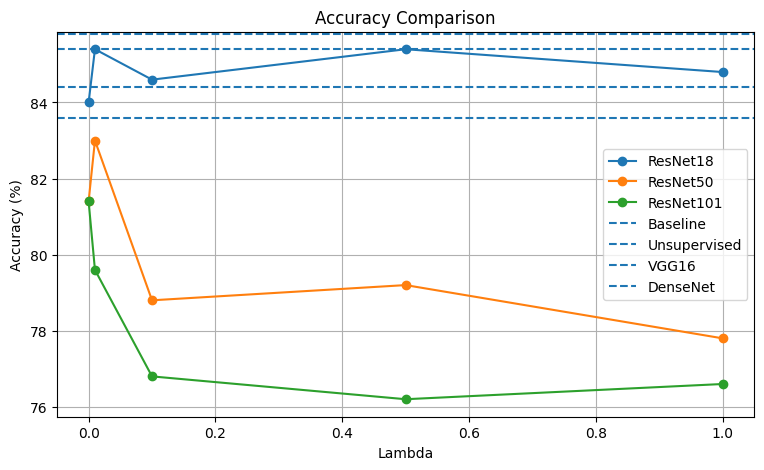

In [21]:
plt.figure(figsize=(9,5))

plt.plot(lambdas, acc_18, marker='o', label="ResNet18")
plt.plot(lambdas, acc_50, marker='o', label="ResNet50")
plt.plot(lambdas, acc_101, marker='o', label="ResNet101")

plt.axhline(acc_baseline, linestyle='--', label="Baseline")
plt.axhline(acc_unsup, linestyle='--', label="Unsupervised")
plt.axhline(acc_vgg, linestyle='--', label="VGG16")
plt.axhline(acc_dense, linestyle='--', label="DenseNet")

plt.xlabel("Lambda")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")

plt.legend()
plt.grid()
plt.show()

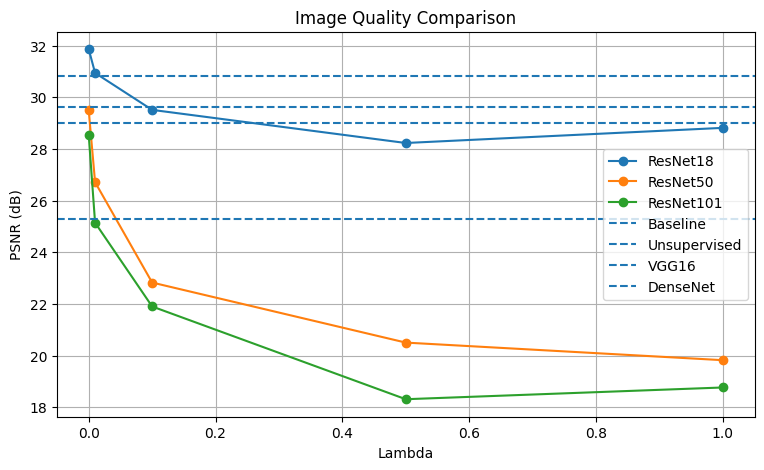

In [22]:
plt.figure(figsize=(9,5))

plt.plot(lambdas, psnr_18, marker='o', label="ResNet18")
plt.plot(lambdas, psnr_50, marker='o', label="ResNet50")
plt.plot(lambdas, psnr_101, marker='o', label="ResNet101")

plt.axhline(psnr_baseline, linestyle='--', label="Baseline")
plt.axhline(psnr_unsup, linestyle='--', label="Unsupervised")
plt.axhline(psnr_vgg, linestyle='--', label="VGG16")
plt.axhline(psnr_dense, linestyle='--', label="DenseNet")

plt.xlabel("Lambda")
plt.ylabel("PSNR (dB)")
plt.title("Image Quality Comparison")

plt.legend()
plt.grid()
plt.show()

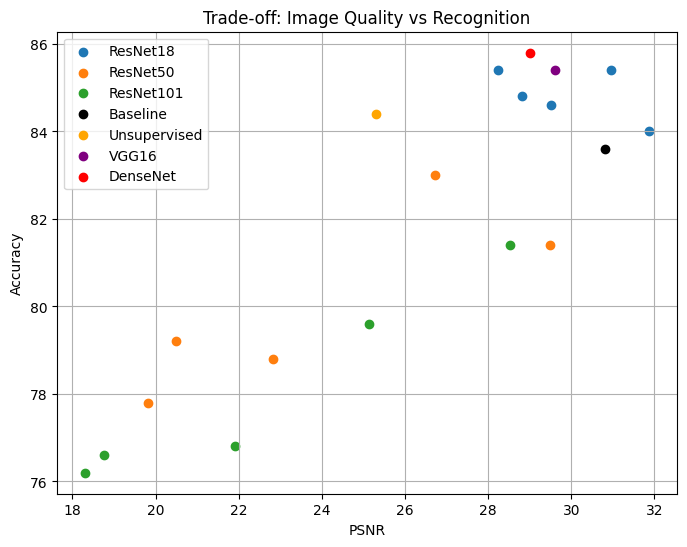

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(psnr_18, acc_18, label="ResNet18")
plt.scatter(psnr_50, acc_50, label="ResNet50")
plt.scatter(psnr_101, acc_101, label="ResNet101")

plt.scatter(psnr_baseline, acc_baseline, label="Baseline", color='black')
plt.scatter(psnr_unsup, acc_unsup, label="Unsupervised", color='orange')
plt.scatter(psnr_vgg, acc_vgg, label="VGG16", color='purple')
plt.scatter(psnr_dense, acc_dense, label="DenseNet", color='red')

plt.xlabel("PSNR")
plt.ylabel("Accuracy")
plt.title("Trade-off: Image Quality vs Recognition")

plt.legend()
plt.grid()
plt.show()